In [52]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [53]:
import yfinance as yf

In [54]:
from datetime import datetime
end = datetime.now()
start = datetime(end.year-20,end.month,end.day)# to get last 20 year data


In [55]:
stock = "AAPL"
google_data = yf.download(stock,start,end) #google data is a variable where we store goggle data

[*********************100%***********************]  1 of 1 completed


In [56]:
google_data.columns = google_data.columns.get_level_values(0)#changes the column names from a MultiIndex (2 levels) to a normal single-level Index.

##  What does get_level_values(0) do?

*It takes only the first level of the column names:
    
*Older versions of yfinance downloaded data with normal column names:

Close High Low Open Volume

*Newer versions return MultiIndex columns, even for a single stock like AAPL. The tutorial you're following was likely created with an older version, so it doesn't include this extra step.

In short: that line converts your downloaded data back into the simpler format expected by the tutorial, allowing the rest of the code to work without changes.

google_data.head() # .head() method used to display the first few rows of your data.

In [57]:
google_data.shape # return dimension of data frame

(5030, 5)

In [58]:
google_data.describe()

Price,Close,High,Low,Open,Volume
count,5029.000000,5029.000000,5029.000000,5029.000000,5.030000e+03
mean,71.767462,72.487193,70.980260,71.705024,3.240275e+08
std,82.209985,83.022612,81.310115,82.114179,3.631523e+08
min,2.002749,2.028472,1.993776,2.012321,1.791060e+07
25%,11.313316,11.470344,11.212522,11.354589,8.228152e+07
50%,27.623222,27.834090,27.468239,27.679713,1.635940e+08
75%,135.688950,137.871071,133.644564,135.447409,4.477725e+08
max,339.786926,344.273097,337.059318,339.736982,3.372970e+09


In [59]:
google_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5030 entries, 2006-08-30 to 2026-08-28
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5029 non-null   float64
 1   High    5029 non-null   float64
 2   Low     5029 non-null   float64
 3   Open    5029 non-null   float64
 4   Volume  5030 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.8 KB


In [60]:
google_data.isna().sum()

Price
Close     1
High      1
Low       1
Open      1
Volume    0
dtype: int64

In [61]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [62]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'closing price of google data')

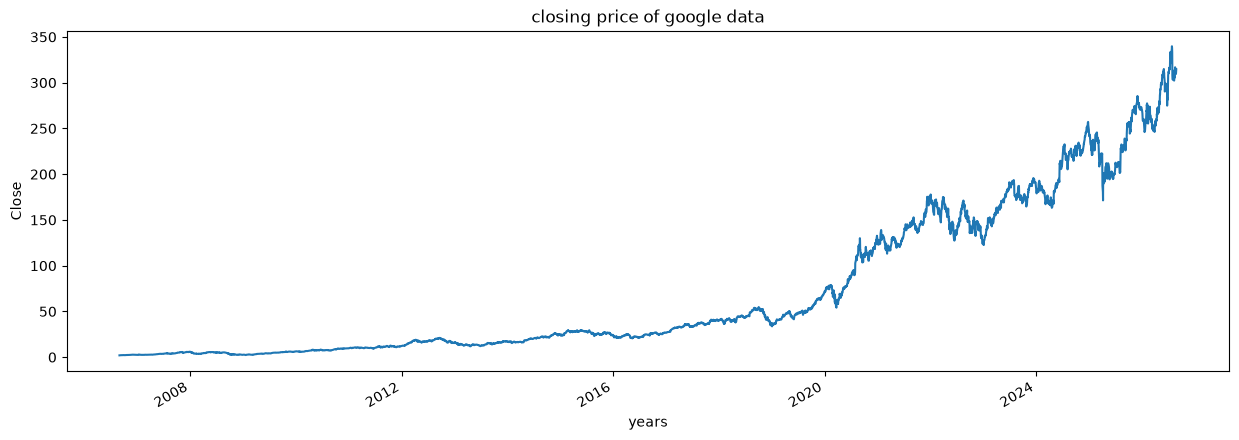

In [63]:
plt.figure(figsize = (15,5))
google_data['Close'].plot()
plt.xlabel("years")
plt.ylabel("Close")
plt.title("closing price of google data")

In [64]:
# if i want to draw same similar graph for other columns do same or create simple function for tht
def plot_graph(figsize, values,column_name): #create a function
    plt.figure(figsize = figsize)
    values.plot()
    plt.xlabel("years")
    plt.ylabel("Column_name")
    plt.title(f"{column_name} of google data")

In [65]:
google_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

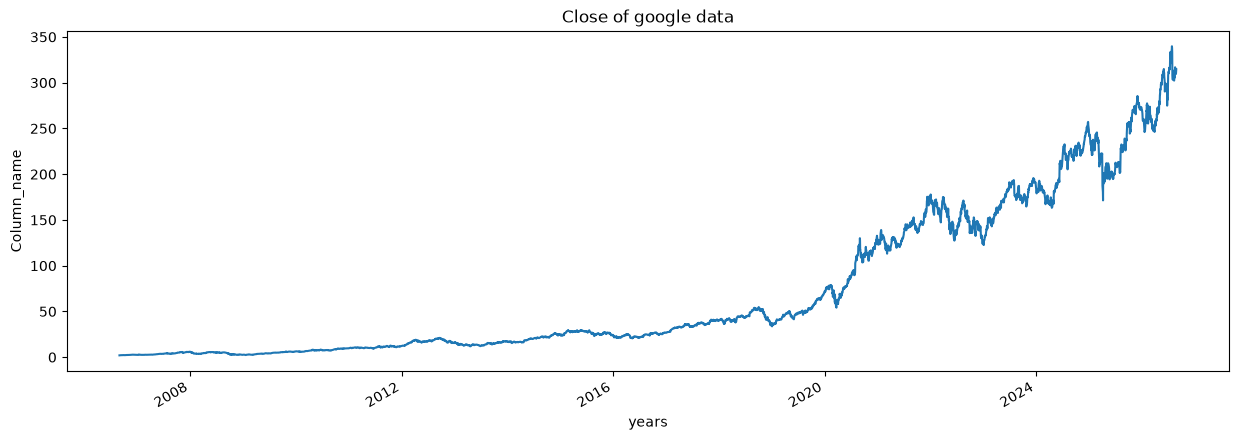

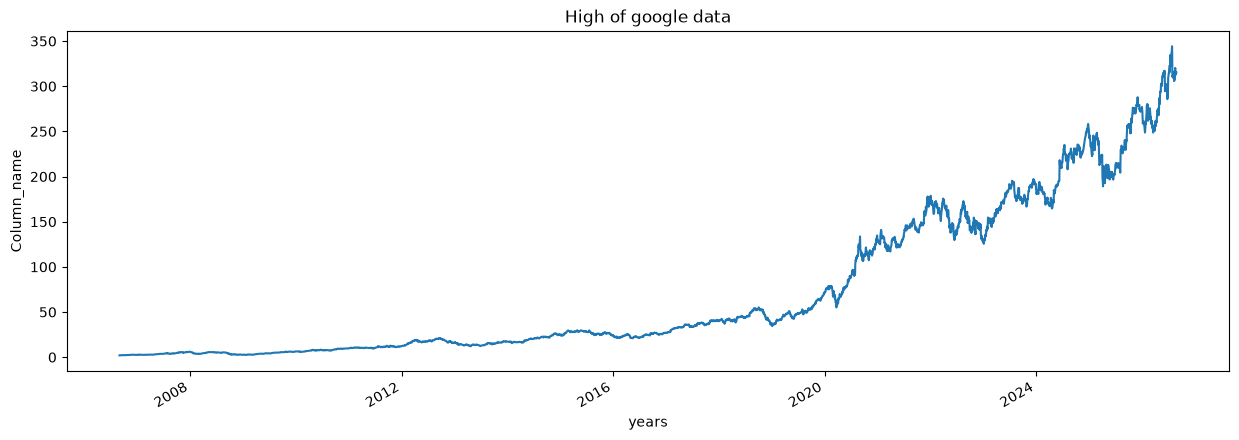

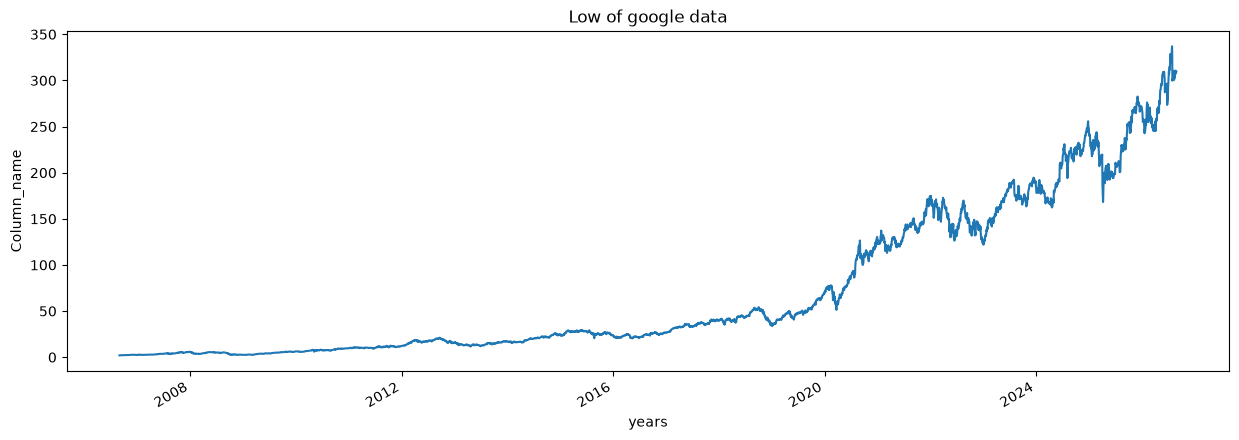

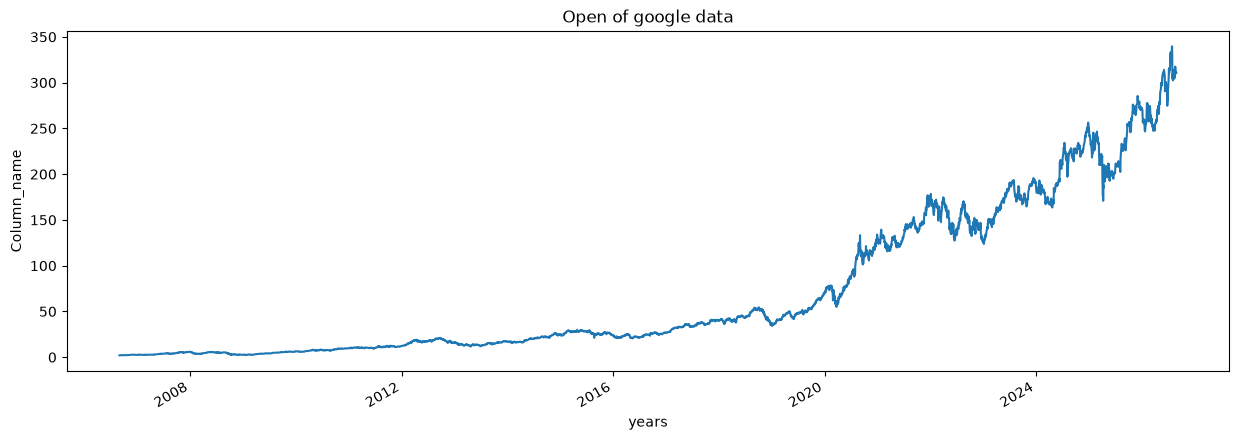

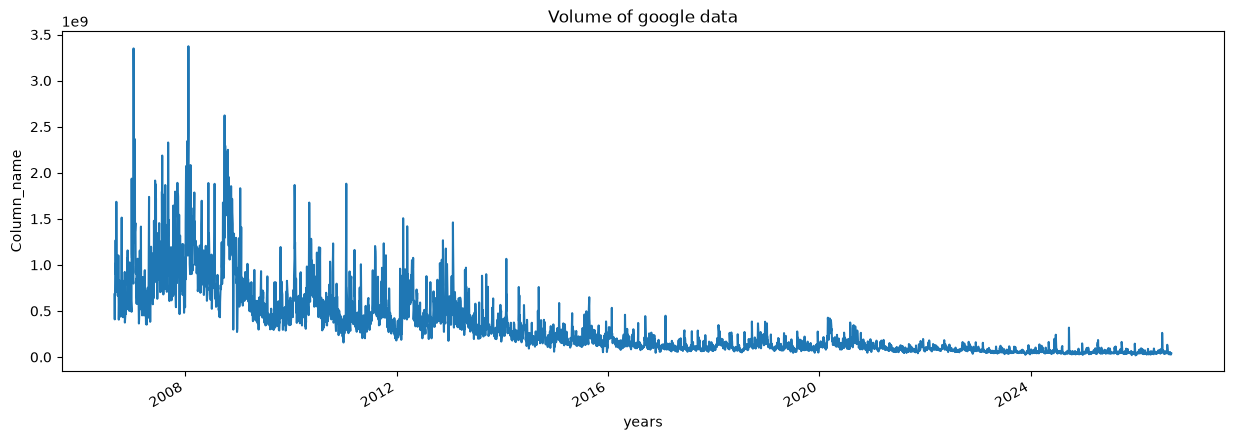

In [66]:
for column in google_data.columns:
    plot_graph((15,5),google_data[column],column)

In [67]:
# MOVING AVERAGE CONCEPT
10,20,30,40,50,60,70,80,90,100

#MA for 5 days ==> null null null null 30,40,50,60,70,80
## First 4 values are NaN because a 5-day moving average needs 5 observations.

(10, 20, 30, 40, 50, 60, 70, 80, 90, 100)

In [68]:
temp_data = [10,20,30,40,50,60,70,80,90,100]
print(sum(temp_data[1:6])/5) #calculating moving average 1st index to 6 index

40.0


In [69]:
import pandas as pd
data = pd.DataFrame([10,20,30,40,50,60,70,80,90,100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [70]:
data.rolling(5).mean() #moving average for 1st 10 values
#using MV concept we predict the stock data

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [71]:
# so i will fill ths training data to a neural network as input training data and predict the next day stock data

In [72]:
for i in range(2004,2026):
    print(i, list(google_data.index.year).count(i))

2004 0
2005 0
2006 85
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252
2025 250


In [73]:
google_data['MA_for_250_days'] = google_data['Close'].rolling(250).mean()
google_data['MA_for_250_days'][0:250].tail()


Date
2007-08-22         NaN
2007-08-23         NaN
2007-08-24         NaN
2007-08-27         NaN
2007-08-28    2.929858
Name: MA_for_250_days, dtype: float64

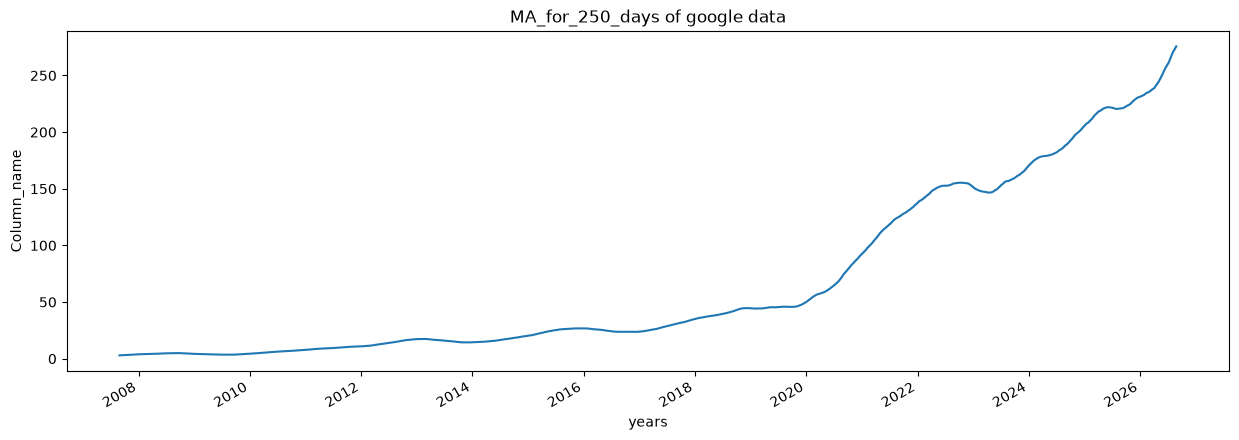

In [74]:
plot_graph((15,5),google_data['MA_for_250_days'], 'MA_for_250_days')

<Figure size 1500x500 with 0 Axes>

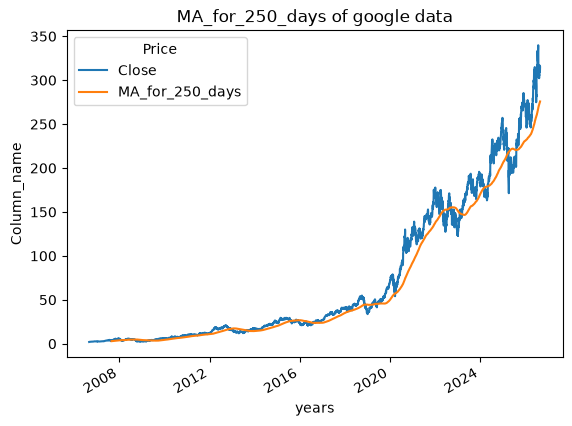

In [75]:
plot_graph((15,5),google_data[['Close','MA_for_250_days']], 'MA_for_250_days')

<Figure size 1500x500 with 0 Axes>

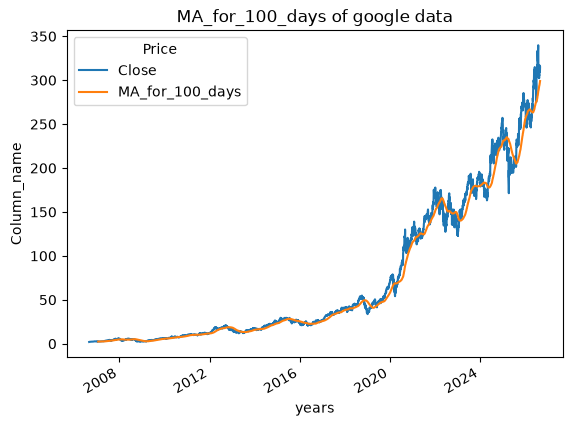

In [76]:
# same graph plot but it is for 100 days
google_data['MA_for_100_days'] = google_data['Close'].rolling(100).mean()
plot_graph((15,5),google_data[['Close','MA_for_100_days']], 'MA_for_100_days')


## NOW I WANT TO DRAW THE 100days and 250 days along with the close price i single graph we can also do that

<Figure size 1500x500 with 0 Axes>

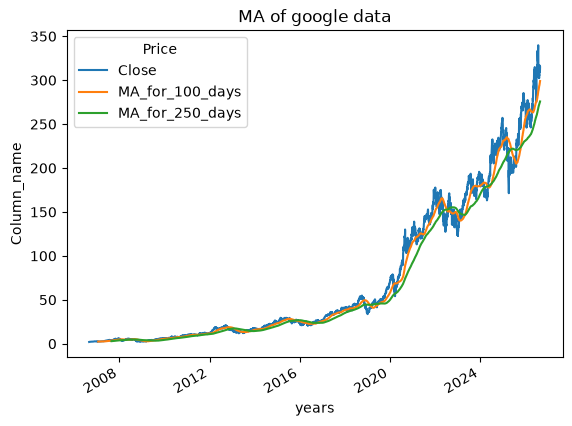

In [77]:
plot_graph((15,5),google_data[['Close','MA_for_100_days','MA_for_250_days']], 'MA')

In [78]:
#Now calculate percentage change in stock
google_data['percentage_change_cp'] = google_data['Close'].pct_change()
google_data[['Close','percentage_change_cp']].head()

Price,Close,percentage_change_cp
Date,,
2006-08-30,2.002749,NaN
2006-08-31,2.029369,0.013291
2006-09-01,2.045221,0.007811
2006-09-05,2.137941,0.045335
2006-09-06,2.094571,-0.020286


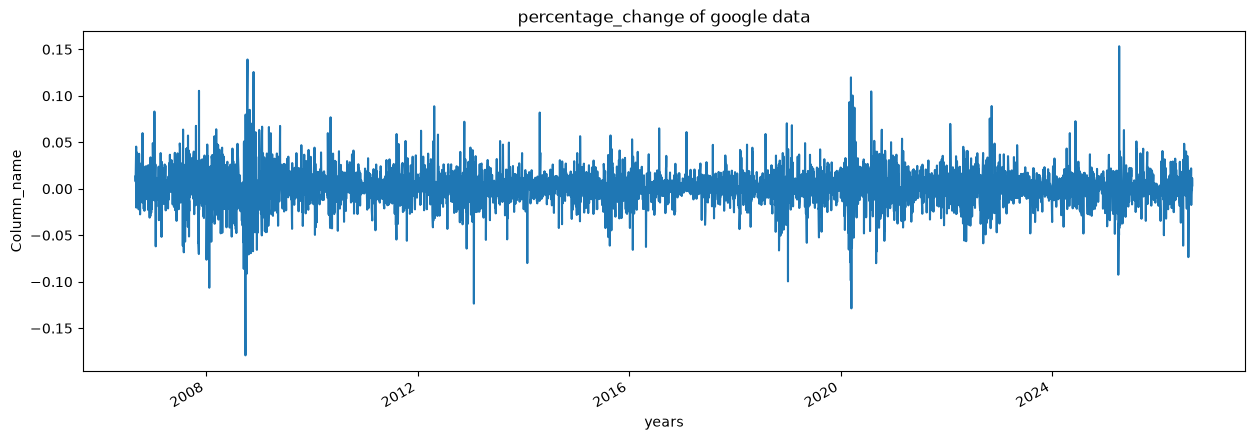

In [79]:
plot_graph((15,5), google_data['percentage_change_cp'],'percentage_change')

In [80]:
#Now preprocessing the data
Close_price = google_data[['Close']]

In [81]:
max(Close_price.values),min(Close_price.values)

(array([339.78692627]), array([2.00274944]))

In [82]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [83]:
# now convert the data in to range of 0 to 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(Close_price)

scaled_data

array([[0.00000000e+00],
       [7.88060430e-05],
       [1.25736047e-04],
       ...,
       [9.22030350e-01],
       [9.25375605e-01],
       [           nan]], shape=(5030, 1))

In [84]:
len(scaled_data)

5030

In [85]:
x_data = []
y_data = []

#1 to 100 10 row
#102 row  2 to 101 5029
for i in range (100, len(scaled_data)):
        x_data.append(scaled_data[i-100:i])
        y_data.append(scaled_data[i])
        
import numpy as np     
x_data,y_data = np.array(x_data),np.array(y_data)

In [86]:
x_data[0],y_data[0]

(array([[0.00000000e+00],
        [7.88060430e-05],
        [1.25736047e-04],
        [4.00231647e-04],
        [2.71834616e-04],
        [5.17108808e-04],
        [4.92319314e-04],
        [4.90546972e-04],
        [5.02060489e-04],
        [6.41076043e-04],
        [6.38421412e-04],
        [6.32223509e-04],
        [6.13630506e-04],
        [6.02999984e-04],
        [7.34933934e-04],
        [6.80921620e-04],
        [5.34820228e-04],
        [7.78322784e-04],
        [9.43019297e-04],
        [8.36764188e-04],
        [8.89890683e-04],
        [8.87236758e-04],
        [6.99513918e-04],
        [6.30451873e-04],
        [7.45562339e-04],
        [6.96857169e-04],
        [6.42844856e-04],
        [6.79150690e-04],
        [6.06541844e-04],
        [5.55186279e-04],
        [7.34933934e-04],
        [7.13684183e-04],
        [7.47329740e-04],
        [6.49044876e-04],
        [6.70297451e-04],
        [1.06521348e-03],
        [1.15022025e-03],
        [1.28392443e-03],
        [1.2

In [87]:
# we will take 70 percent of data as a training data and 30 percent as a testing data
len(x_data)*0.7

3451.0

In [88]:
5029-100-int(len(x_data)*0.7) # -100 bcz first are null values but we need previous 100 day values

1478

In [89]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[:splitting_len:]
y_test = y_data[:splitting_len:]
#And int() is important because slicing needs an integer index.

In [90]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(3451, 100, 1)
(3451, 1)
(3451, 100, 1)
(3451, 1)


## START BUILDING NEURAL NETWORK TO PREDICT THE CLOSING PRICE

In [91]:
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

c:\Users\Niraj kumar\OneDrive\Desktop\PROJECTS\STOCK PRICE\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [92]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [93]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [94]:
model.fit(x_train,y_train,batch_size=1, epochs = 2)

Epoch 1/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 103s 27ms/step - loss: 1.2948e-04
Epoch 2/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 74s 22ms/step - loss: 6.3482e-05


In [95]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

## PREDICTING THE TEST DATA

In [96]:
predictions = model.predict(x_test)

108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step


In [97]:
predictions

array([[0.00311135],
       [0.00310321],
       [0.00309381],
       ...,
       [0.31900555],
       [0.31927472],
       [0.31675476]], shape=(3451, 1), dtype=float32)

##  SEE

* We do this because neural networks, including LSTMs, generally train more effectively when numerical inputs are on a normalized scale rather than having potentially large/raw values.
* Original data
* ₹100 ─────────────── ₹250
*       ↓ scaling
* 0.00 ─────────────── 1.00
*       ↓
*       LSTM
*       ↓
*     0.72
*       ↓ inverse_transform()
*      ↓
*      ₹208
*    0.72  →  ₹208
    
 
* We use inverse transformation because the LSTM is trained on normalized 0–1 values. After prediction, we convert those normalized predictions back to the original stock-price scale so that we can interpret the results in actual currency, compare them with actual prices, calculate an interpretable RMSE, and visualize the predictions.

In [98]:
# we need to inverse them to get our original data


inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[  3.0537152],
       [  3.0509632],
       [  3.0477884],
       ...,
       [109.757774 ],
       [109.8487   ],
       [108.9975   ]], shape=(3451, 1), dtype=float32)

In [99]:

inv_y_test = scaler.inverse_transform(y_test)

inv_y_test

array([[  2.57970572],
       [  2.553684  ],
       [  2.57043409],
       ...,
       [112.9045639 ],
       [109.6676178 ],
       [111.52837372]], shape=(3451, 1))

In [100]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))
rmse

np.float64(0.9756257505905388)

In [51]:
#lets see in graph format predicted value to original value
#This code is creating a Pandas DataFrame that puts your actual stock prices and predicted stock prices side-by-side with their dates.
ploting_data = pd.DataFrame(
{
    'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
    
},
    index = google_data.index[:splitting_len]
)
ploting_data.head()


,original_test_data,predictions
Date,,
2006-08-30,2.579705,0.609347
2006-08-31,2.553685,0.611025
2006-09-01,2.570434,0.599041
2006-09-05,2.558769,0.592695
2006-09-06,2.564153,0.582894


<Figure size 1500x600 with 0 Axes>

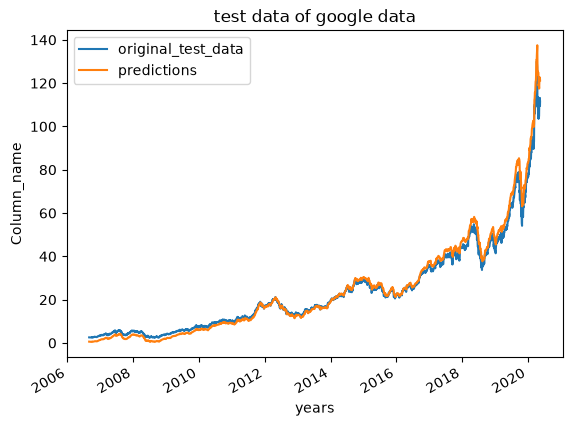

In [101]:
plot_graph((15,6), ploting_data, 'test data')

## Create a 15×6 graph using the original stock prices up to the prediction period, append the actual test prices and model predictions, and plot the complete stock-price history

<Figure size 1500x600 with 0 Axes>

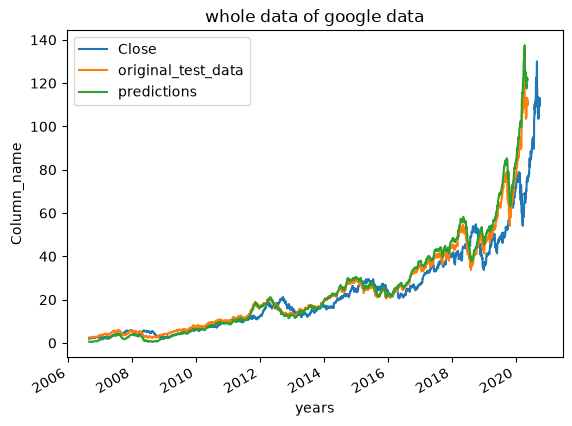

In [102]:
# lets plot the graph with whole data so lets do that we need to combine our ploting to original data set
plot_graph((15,6), pd.concat([Close_price[:splitting_len+100],ploting_data],axis=0), 'whole data')


In [103]:
model.save("Latest_stock_price_model.keras")

## 1. Get historical stock data
          ↓
2. Select required column
          ↓
3. Visualize historical price
          ↓
4. Preprocess the data
          ↓
5. Normalize data (0–1)
          ↓
6. Create sequences of 100 days
          ↓
7. Split into training & testing
          ↓
8. Build LSTM model
          ↓
9. Train the model
          ↓
10. Predict test data
          ↓
11. Convert predictions back to ₹
          ↓
12. Calculate RMSE
          ↓
13. Compare Actual vs Predicted
          ↓
14. Plot the results
          ↓
15. Use latest 100 days → predict future price

## "I developed a stock price prediction system using an LSTM neural network. First, I collected historical stock data and selected the closing price. I normalized the data using MinMaxScaler because LSTM models perform better with normalized inputs. I then created sequences using the previous 100 trading days to predict the next day's closing price. I divided these sequences into training and testing datasets, trained a stacked LSTM model, and generated predictions on unseen test data. Finally, I converted the scaled predictions back to the original price scale using inverse transformation, evaluated the model using RMSE, and visualized the actual and predicted stock prices."